# Modul 2: Paralelisasi CPU dengan OpenMP
## Setup dan Verifikasi Lingkungan

In [1]:
import subprocess, os, platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Verifikasi GCC dan OpenMP
result = subprocess.run(['gcc', '--version'], capture_output=True, text=True)
print('=== GCC Version ===')
print(result.stdout.split('\n')[0])

result2 = subprocess.run('echo | cpp -fopenmp -dM | grep -i openmp',
                         shell=True, capture_output=True, text=True)
print('\n=== OpenMP Support ===')
print(result2.stdout if result2.stdout else 'OpenMP tidak terdeteksi!')
print(f'\nJumlah CPU cores: {os.cpu_count()}')
print(f'Sistem Operasi   : {platform.system()} {platform.release()}')

=== GCC Version ===
gcc (Ubuntu 15.2.0-16ubuntu1) 15.2.0

=== OpenMP Support ===
#define _OPENMP 201511


Jumlah CPU cores: 8
Sistem Operasi   : Linux 6.6.87.2-microsoft-standard-WSL2


In [2]:
# Buat direktori kerja untuk file C
os.makedirs('openmp_files', exist_ok=True)
print('Direktori openmp_files siap.')

Direktori openmp_files siap.


## Langkah 2: Test Hello World OpenMP

In [4]:
%%writefile openmp_files/test_openmp.c
#include <stdio.h>
#include <omp.h>

int main() {
    printf("Total threads tersedia: %d\n", omp_get_max_threads());
    #pragma omp parallel
    {
        int id = omp_get_thread_num();
        printf("Hello dari thread %d\n", id);
    }
    return 0;
}

Writing openmp_files/test_openmp.c


In [5]:
# Kompilasi dan jalankan
!gcc -fopenmp openmp_files/test_openmp.c -o openmp_files/test_openmp
!./openmp_files/test_openmp

Total threads tersedia: 8
Hello dari thread 4
Hello dari thread 1
Hello dari thread 7
Hello dari thread 0
Hello dari thread 3
Hello dari thread 5
Hello dari thread 6
Hello dari thread 2


## Langkah 3: Perkalian Matriks Serial (Baseline)

In [6]:
%%writefile openmp_files/matrix_serial.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

#define N 1024

void matrix_multiply_serial(double A[N][N], double B[N][N], double C[N][N]) {
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }
}

int main() {
    static double A[N][N], B[N][N], C[N][N];
    srand(42);
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }
    struct timespec start, end;
    clock_gettime(CLOCK_MONOTONIC, &start);
    matrix_multiply_serial(A, B, C);
    clock_gettime(CLOCK_MONOTONIC, &end);
    double elapsed = (end.tv_sec - start.tv_sec) +
                     (end.tv_nsec - start.tv_nsec) / 1e9;
    double gflops = (2.0 * N * N * N) / (elapsed * 1e9);
    printf("SERIAL_TIME=%.4f\n", elapsed);
    printf("SERIAL_GFLOPS=%.4f\n", gflops);
    return 0;
}

Writing openmp_files/matrix_serial.c


In [7]:
# Kompilasi
!gcc -O2 openmp_files/matrix_serial.c -o openmp_files/matrix_serial

# Jalankan dan simpan hasilnya ke variabel Python
result = subprocess.run('./openmp_files/matrix_serial', capture_output=True, text=True)
output = result.stdout
print(output)

# Parse hasil
serial_time = float([l.split('=')[1] for l in output.split('\n') if 'SERIAL_TIME' in l][0])
serial_gflops = float([l.split('=')[1] for l in output.split('\n') if 'SERIAL_GFLOPS' in l][0])
print(f'Waktu Serial  : {serial_time:.4f} detik')
print(f'Serial GFLOPS : {serial_gflops:.4f}')

SERIAL_TIME=26.1066
SERIAL_GFLOPS=0.0823

Waktu Serial  : 26.1066 detik
Serial GFLOPS : 0.0823


## Langkah 4: Perkalian Matriks Paralel + Speedup Analysis

In [8]:
%%writefile openmp_files/matrix_parallel.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>
#include <time.h>

#define N 1024

int main(int argc, char* argv[]) {
    int num_threads = (argc > 1) ? atoi(argv[1]) : 4;
    omp_set_num_threads(num_threads);
    static double A[N][N], B[N][N], C[N][N];
    srand(42);
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }
    double start = omp_get_wtime();
    #pragma omp parallel for
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }
    double end = omp_get_wtime();
    printf("THREADS=%d TIME=%.4f\n", num_threads, end - start);
    return 0;
}

Writing openmp_files/matrix_parallel.c


In [9]:
!gcc -fopenmp -O2 openmp_files/matrix_parallel.c -o openmp_files/matrix_parallel

# Eksperimen dengan berbagai jumlah thread
thread_counts = [1, 2, 4, 8, 16]
parallel_times = []

for t in thread_counts:
    res = subprocess.run(f'./openmp_files/matrix_parallel {t}',
                         shell=True, capture_output=True, text=True)
    line = res.stdout.strip()
    time_val = float(line.split('TIME=')[1])
    parallel_times.append(time_val)
    print(f'Threads={t:2d}: {time_val:.4f} detik')

# Hitung Speedup dan Efficiency
speedups    = [serial_time / t for t in parallel_times]
efficiencies = [(s / th) * 100 for s, th in zip(speedups, thread_counts)]

df_speedup = pd.DataFrame({
    'Jumlah Thread': thread_counts,
    'Waktu (detik)': [f'{t:.4f}' for t in parallel_times],
    'Speedup'       : [f'{s:.3f}' for s in speedups],
    'Efficiency (%)':[f'{e:.1f}' for e in efficiencies]
})
print('\n--- Tabel Speedup Analysis ---')
print(df_speedup.to_string(index=False))

Threads= 1: 8.0526 detik
Threads= 2: 3.8706 detik
Threads= 4: 2.2816 detik
Threads= 8: 1.7486 detik
Threads=16: 1.6220 detik

--- Tabel Speedup Analysis ---
 Jumlah Thread Waktu (detik) Speedup Efficiency (%)
             1        8.0526   3.242          324.2
             2        3.8706   6.745          337.2
             4        2.2816  11.442          286.1
             8        1.7486  14.930          186.6
            16        1.6220  16.095          100.6


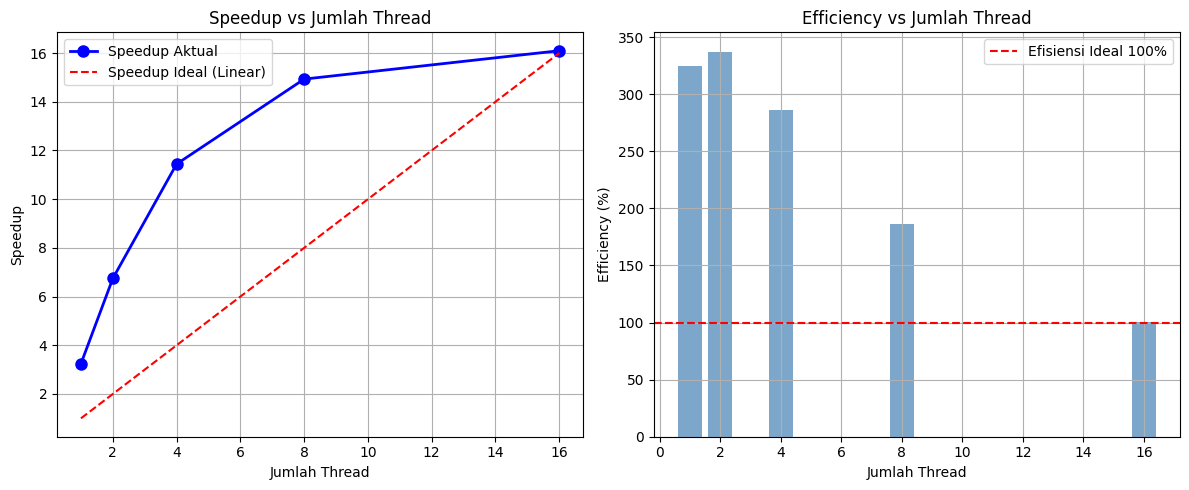

Grafik disimpan ke openmp_files/speedup_analysis.png


In [10]:
# Visualisasi Speedup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(thread_counts, speedups, 'bo-', linewidth=2, markersize=8, label='Speedup Aktual')
axes[0].plot(thread_counts, thread_counts, 'r--', label='Speedup Ideal (Linear)')
axes[0].set_xlabel('Jumlah Thread'); axes[0].set_ylabel('Speedup')
axes[0].set_title('Speedup vs Jumlah Thread'); axes[0].legend(); axes[0].grid(True)

axes[1].bar(thread_counts, efficiencies, color='steelblue', alpha=0.7)
axes[1].axhline(y=100, color='r', linestyle='--', label='Efisiensi Ideal 100%')
axes[1].set_xlabel('Jumlah Thread'); axes[1].set_ylabel('Efficiency (%)')
axes[1].set_title('Efficiency vs Jumlah Thread'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('openmp_files/speedup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke openmp_files/speedup_analysis.png')

## Langkah 5: Eksperimen Scheduling Strategies

In [11]:
%%writefile openmp_files/matrix_schedule.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define N 1024
#define NUM_THREADS 4

int main(int argc, char* argv[]) {
    // argv[1]=schedule_type (static/dynamic/guided), argv[2]=chunk_size
    char *sched = (argc > 1) ? argv[1] : "static";
    int chunk   = (argc > 2) ? atoi(argv[2]) : 64;
    static double A[N][N], B[N][N], C[N][N];
    srand(42);
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }
    omp_set_num_threads(NUM_THREADS);
    char env_str[64];
    snprintf(env_str, 64, "%s,%d", sched, chunk);
    setenv("OMP_SCHEDULE", env_str, 1);
    double start = omp_get_wtime();
    #pragma omp parallel for schedule(runtime)
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }
    double end = omp_get_wtime();
    printf("SCHED=%s CHUNK=%d TIME=%.4f\n", sched, chunk, end - start);
    return 0;
}

Writing openmp_files/matrix_schedule.c


In [12]:
!gcc -fopenmp -O2 openmp_files/matrix_schedule.c -o openmp_files/matrix_schedule

schedules   = ['static', 'dynamic', 'guided']
chunk_sizes = [16, 64, 256, 1024]
sched_results = {}

for sched in schedules:
    times = []
    for chunk in chunk_sizes:
        res = subprocess.run(f'./openmp_files/matrix_schedule {sched} {chunk}',
                             shell=True, capture_output=True, text=True)
        t = float(res.stdout.split('TIME=')[1].strip())
        times.append(t)
        print(f'{sched:8s} chunk={chunk:4d}: {t:.4f} detik')
    sched_results[sched] = times

print('\nEksperimen Scheduling selesai!')

static   chunk=  16: 2.6521 detik
static   chunk=  64: 2.3003 detik
static   chunk= 256: 2.1484 detik
static   chunk=1024: 2.2396 detik
dynamic  chunk=  16: 2.2701 detik
dynamic  chunk=  64: 2.1366 detik
dynamic  chunk= 256: 2.2209 detik
dynamic  chunk=1024: 2.1373 detik
guided   chunk=  16: 2.1701 detik
guided   chunk=  64: 2.1968 detik
guided   chunk= 256: 2.0604 detik
guided   chunk=1024: 1.9815 detik

Eksperimen Scheduling selesai!



--- STATIC Scheduling ---
 Chunk Size Waktu (detik) Speedup
         16        2.6521   9.844
         64        2.3003  11.349
        256        2.1484  12.152
       1024        2.2396  11.657

--- DYNAMIC Scheduling ---
 Chunk Size Waktu (detik) Speedup
         16        2.2701  11.500
         64        2.1366  12.219
        256        2.2209  11.755
       1024        2.1373  12.215

--- GUIDED Scheduling ---
 Chunk Size Waktu (detik) Speedup
         16        2.1701  12.030
         64        2.1968  11.884
        256        2.0604  12.671
       1024        1.9815  13.175


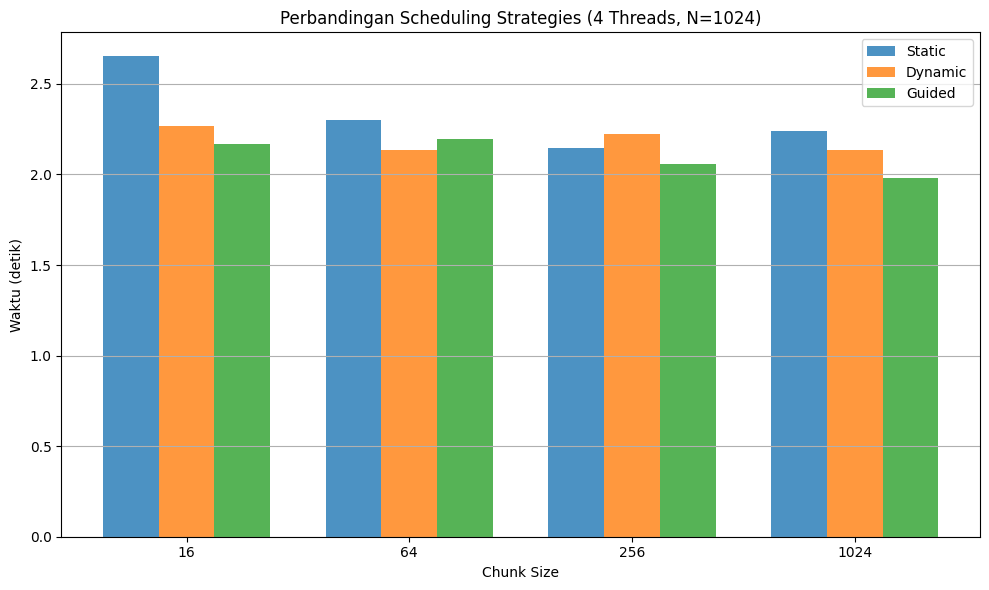

In [13]:
# Tabel dan visualisasi scheduling
for sched, times in sched_results.items():
    df = pd.DataFrame({'Chunk Size': chunk_sizes,
                       'Waktu (detik)': [f'{t:.4f}' for t in times],
                       'Speedup': [f'{serial_time/t:.3f}' for t in times]})
    print(f'\n--- {sched.upper()} Scheduling ---')
    print(df.to_string(index=False))

# Bar chart perbandingan
x = np.arange(len(chunk_sizes))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
for i, (sched, times) in enumerate(sched_results.items()):
    ax.bar(x + i*width, times, width, label=sched.capitalize(), alpha=0.8)
ax.set_xlabel('Chunk Size'); ax.set_ylabel('Waktu (detik)')
ax.set_title('Perbandingan Scheduling Strategies (4 Threads, N=1024)')
ax.set_xticks(x + width); ax.set_xticklabels(chunk_sizes)
ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('openmp_files/scheduling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Langkah 6: Investigasi False Sharing

In [14]:
%%writefile openmp_files/false_sharing.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define N 1000000
#define CACHE_LINE_SIZE 65
#define NUM_THREADS 16

// Teknik 1: Dengan False Sharing
double with_false_sharing() {
    int array[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) array[id]++; }
    return omp_get_wtime() - start;
}

// Teknik 2: Padding untuk menghindari false sharing
typedef struct { int value; char pad[CACHE_LINE_SIZE - sizeof(int)]; } PaddedInt;
double with_padding() {
    PaddedInt array[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) array[id].value++; }
    return omp_get_wtime() - start;
}

// Teknik 3: Private variable (reduction)
double with_private_var() {
    int results[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int local = 0; int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) local++;
      results[id] = local; }
    return omp_get_wtime() - start;
}

int main() {
    double t1 = with_false_sharing();
    double t2 = with_padding();
    double t3 = with_private_var();
    printf("FS_TIME=%.4f\n", t1);
    printf("PAD_TIME=%.4f\n", t2);
    printf("PRIV_TIME=%.4f\n", t3);
    return 0;
}

Writing openmp_files/false_sharing.c


            Implementasi Waktu Rata-rata (detik) Improvement (%)
    Dengan False Sharing              0.00430000               -
    Padding (Mitigasi 1)              0.00088000          79.53%
Private Var (Mitigasi 2)              0.00082000          80.93%


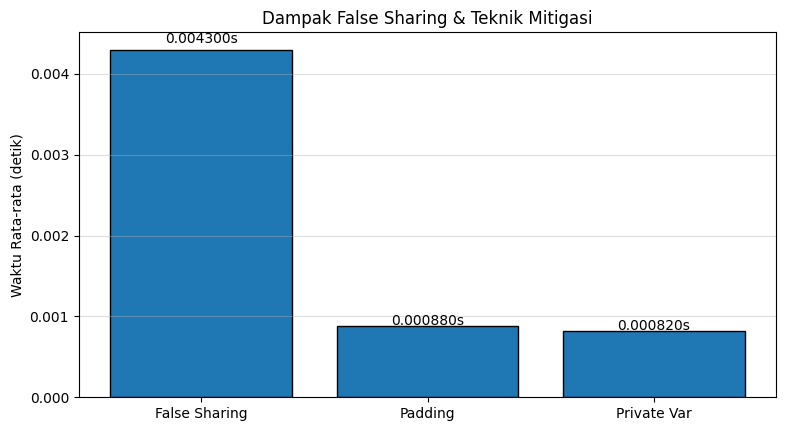

In [15]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# Compile
!gcc -fopenmp -O2 openmp_files/false_sharing.c -o openmp_files/false_sharing

# Jalankan benchmark beberapa kali
runs = 5
fs_times, pad_times, priv_times = [], [], []

for _ in range(runs):
    res = subprocess.run(
        './openmp_files/false_sharing',
        capture_output=True,
        text=True
    )

    out = res.stdout.splitlines()

    fs_times.append(float([l.split('=')[1] for l in out if 'FS_TIME' in l][0]))
    pad_times.append(float([l.split('=')[1] for l in out if 'PAD_TIME' in l][0]))
    priv_times.append(float([l.split('=')[1] for l in out if 'PRIV_TIME' in l][0]))

# Rata-rata
avg_fs   = sum(fs_times) / runs
avg_pad  = sum(pad_times) / runs
avg_priv = sum(priv_times) / runs

# Improvement
imp_pad  = (1 - avg_pad / avg_fs) * 100
imp_priv = (1 - avg_priv / avg_fs) * 100

# Tampilkan lebih presisi
df_fs = pd.DataFrame({
    'Implementasi': [
        'Dengan False Sharing',
        'Padding (Mitigasi 1)',
        'Private Var (Mitigasi 2)'
    ],
    'Waktu Rata-rata (detik)': [
        f'{avg_fs:.8f}',
        f'{avg_pad:.8f}',
        f'{avg_priv:.8f}'
    ],
    'Improvement (%)': [
        '-',
        f'{imp_pad:.2f}%',
        f'{imp_priv:.2f}%'
    ]
})

print(df_fs.to_string(index=False))

# Visualisasi
labels = ['False Sharing', 'Padding', 'Private Var']
avgs   = [avg_fs, avg_pad, avg_priv]

plt.figure(figsize=(9, 5))

bars = plt.bar(labels, avgs, edgecolor='black')

for bar, val in zip(bars, avgs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.02,
        f'{val:.6f}s',
        ha='center',
        fontsize=10
    )

plt.ylabel('Waktu Rata-rata (detik)')
plt.title('Dampak False Sharing & Teknik Mitigasi')

plt.grid(axis='y', alpha=0.4)

# Hindari warning tight_layout
plt.subplots_adjust(top=0.88, bottom=0.15)

plt.savefig(
    'openmp_files/false_sharing_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Langkah 7: Eksperimen Tambahan – Variasi Ukuran Matriks (opsional)

In [16]:
%%writefile openmp_files/matrix_sizes.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 512;
    int T = (argc > 2) ? atoi(argv[2]) : 4;
    omp_set_num_threads(T);
    double *A = malloc(N*N*sizeof(double));
    double *B = malloc(N*N*sizeof(double));
    double *C = malloc(N*N*sizeof(double));
    if (!A || !B || !C) { printf("Alokasi gagal\n"); return 1; }
    srand(42);
    for (int i = 0; i < N*N; i++) {
        A[i] = (double)rand()/RAND_MAX;
        B[i] = (double)rand()/RAND_MAX; }
    double start = omp_get_wtime();
    #pragma omp parallel for
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            double sum = 0;
            for (int k = 0; k < N; k++)
                sum += A[i*N+k] * B[k*N+j];
            C[i*N+j] = sum;
        }
    printf("N=%d T=%d TIME=%.4f\n", N, T, omp_get_wtime()-start);
    free(A); free(B); free(C);
    return 0;
}

Writing openmp_files/matrix_sizes.c


In [17]:
!gcc -fopenmp -O2 openmp_files/matrix_sizes.c -o openmp_files/matrix_sizes

matrix_sizes = [256, 512, 1024, 2048]
thread_test  = [1, 2, 4, 8]
size_results = {n: [] for n in matrix_sizes}

for n in matrix_sizes:
    print(f'--- N={n} ---')
    for t in thread_test:
        res = subprocess.run(f'./openmp_files/matrix_sizes {n} {t}',
                             shell=True, capture_output=True, text=True)
        line = res.stdout.strip()
        if 'TIME=' in line:
            time_val = float(line.split('TIME=')[1])
            size_results[n].append(time_val)
            print(f'  Threads={t}: {time_val:.4f}s')
        else:
            size_results[n].append(None)
            print(f'  Threads={t}: ERROR')

print('\nEksperimen ukuran matriks selesai!')

--- N=256 ---
  Threads=1: 0.0665s
  Threads=2: 0.0310s
  Threads=4: 0.0164s
  Threads=8: 0.0193s
--- N=512 ---
  Threads=1: 1.4427s
  Threads=2: 0.7306s
  Threads=4: 0.3151s
  Threads=8: 0.2686s
--- N=1024 ---
  Threads=1: 24.5603s
  Threads=2: 11.2252s
  Threads=4: 5.2845s
  Threads=8: 3.5106s
--- N=2048 ---
  Threads=1: 384.5274s
  Threads=2: 154.6660s
  Threads=4: 64.8071s
  Threads=8: 35.7503s

Eksperimen ukuran matriks selesai!


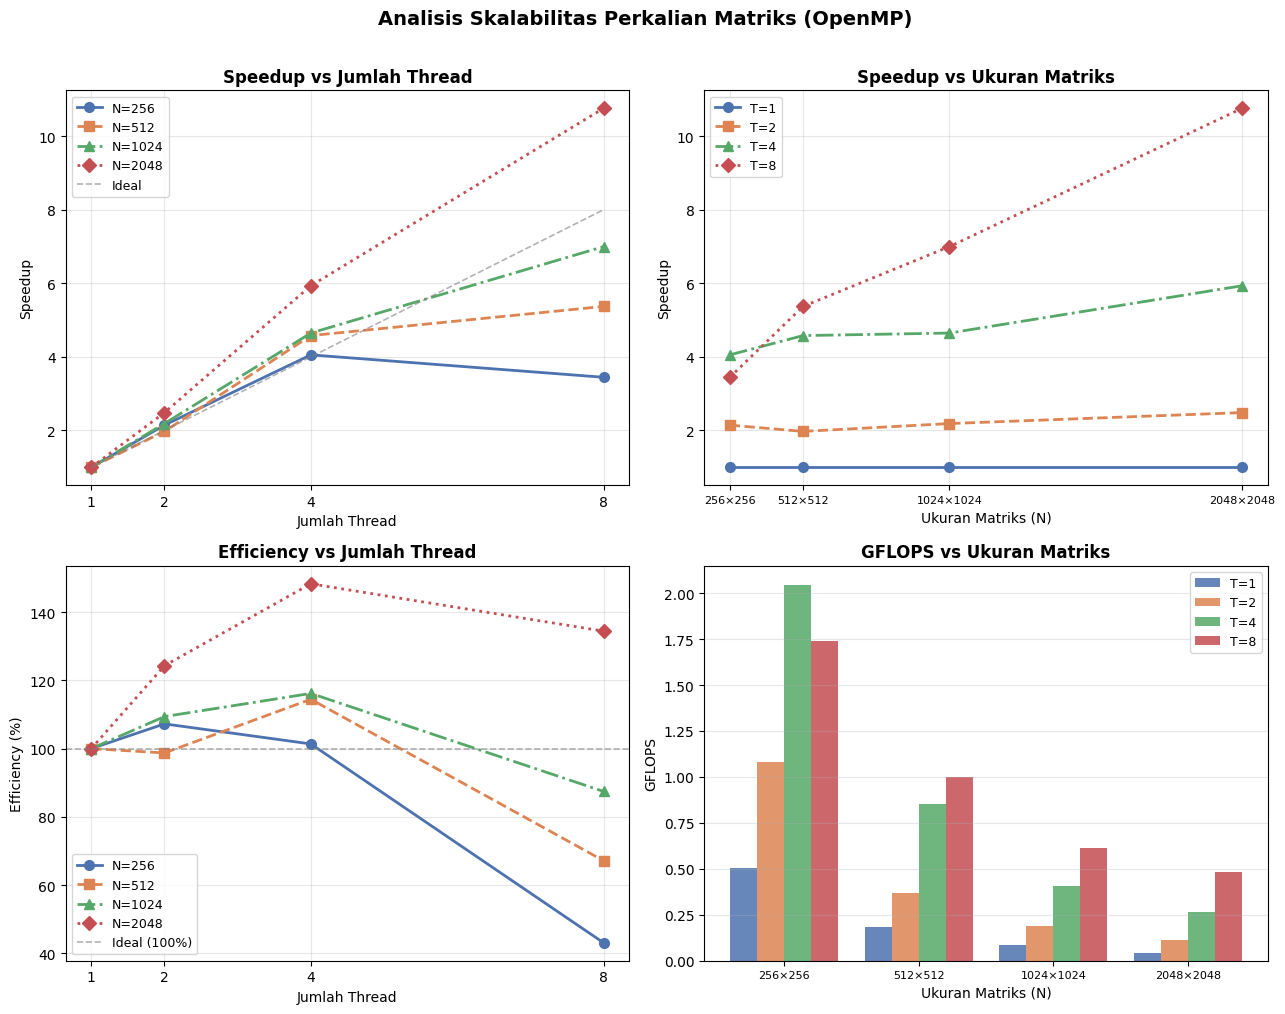

Grafik disimpan sebagai scalability_analysis.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data hasil eksperimen
matrix_sizes = [256, 512, 1024, 2048]
thread_counts = [1, 2, 4, 8]

# Waktu dari hasil eksperimen (detik)
size_results = {
    256:  [0.0665, 0.0310, 0.0164, 0.0193],
    512:  [1.4427, 0.7306, 0.3151, 0.2686],
    1024: [24.5603, 11.2252, 5.2845, 3.5106],
    2048: [384.5274, 154.6660, 64.8071, 35.7503]
}

# Hitung speedup: serial (T=1) / waktu paralel
speedup_results = {}
for n in matrix_sizes:
    serial_time = size_results[n][0]
    speedup_results[n] = [serial_time / t for t in size_results[n]]

# Hitung GFLOPS: (2 * N^3) / (waktu * 1e9)
gflops_results = {}
for n in matrix_sizes:
    gflops_results[n] = [(2 * n**3) / (t * 1e9) for t in size_results[n]]

# Hitung efficiency: (speedup / jumlah_thread) * 100
efficiency_results = {}
for n in matrix_sizes:
    efficiency_results[n] = [(speedup_results[n][i] / thread_counts[i]) * 100
                              for i in range(len(thread_counts))]

# ── Warna per ukuran matriks ──────────────────────────────────────────────────
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
markers   = ['o', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Analisis Skalabilitas Perkalian Matriks (OpenMP)', fontsize=14, fontweight='bold', y=1.01)

# ── Grafik 1: Speedup vs Jumlah Thread ───────────────────────────────────────
ax1 = axes[0, 0]
for i, n in enumerate(matrix_sizes):
    ax1.plot(thread_counts, speedup_results[n],
             color=colors[i], marker=markers[i], linestyle=linestyles[i],
             linewidth=2, markersize=7, label=f'N={n}')
ax1.plot(thread_counts, thread_counts,
         color='gray', linestyle='--', linewidth=1.2, alpha=0.6, label='Ideal')
ax1.set_title('Speedup vs Jumlah Thread', fontweight='bold')
ax1.set_xlabel('Jumlah Thread')
ax1.set_ylabel('Speedup')
ax1.set_xticks(thread_counts)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Grafik 2: Speedup vs Ukuran Matriks (per thread) ─────────────────────────
ax2 = axes[0, 1]
thread_colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
thread_markers = ['o', 's', '^', 'D']
for i, t in enumerate(thread_counts):
    sp = [speedup_results[n][i] for n in matrix_sizes]
    ax2.plot(matrix_sizes, sp,
             color=thread_colors[i], marker=thread_markers[i],
             linestyle=linestyles[i], linewidth=2, markersize=7, label=f'T={t}')
ax2.set_title('Speedup vs Ukuran Matriks', fontweight='bold')
ax2.set_xlabel('Ukuran Matriks (N)')
ax2.set_ylabel('Speedup')
ax2.set_xticks(matrix_sizes)
ax2.set_xticklabels([f'{n}×{n}' for n in matrix_sizes], fontsize=8)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# ── Grafik 3: Efficiency vs Jumlah Thread ────────────────────────────────────
ax3 = axes[1, 0]
for i, n in enumerate(matrix_sizes):
    ax3.plot(thread_counts, efficiency_results[n],
             color=colors[i], marker=markers[i], linestyle=linestyles[i],
             linewidth=2, markersize=7, label=f'N={n}')
ax3.axhline(y=100, color='gray', linestyle='--', linewidth=1.2, alpha=0.6, label='Ideal (100%)')
ax3.set_title('Efficiency vs Jumlah Thread', fontweight='bold')
ax3.set_xlabel('Jumlah Thread')
ax3.set_ylabel('Efficiency (%)')
ax3.set_xticks(thread_counts)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# ── Grafik 4: GFLOPS vs Ukuran Matriks ───────────────────────────────────────
ax4 = axes[1, 1]
x      = np.arange(len(matrix_sizes))
width  = 0.2
for i, t in enumerate(thread_counts):
    gf = [gflops_results[n][i] for n in matrix_sizes]
    ax4.bar(x + i * width, gf,
            width=width, color=thread_colors[i],
            label=f'T={t}', alpha=0.85)
ax4.set_title('GFLOPS vs Ukuran Matriks', fontweight='bold')
ax4.set_xlabel('Ukuran Matriks (N)')
ax4.set_ylabel('GFLOPS')
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels([f'{n}×{n}' for n in matrix_sizes], fontsize=8)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('scalability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan sebagai scalability_analysis.png')